In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.stats import multivariate_normal
from matplotlib.patches import Ellipse
import matplotlib.gridspec as gridspec

np.random.seed(42)



# TP : TRANSPORT ENTRE DISTRIBUTIONS — DU SIMPLE AU SCHRÖDINGER BRIDGE

Ce TP explore trois façons de "passer" d'une distribution mu_0 à mu_1 :

- Partie 1 — Interpolation linéaire déterministe   (la plus simple)
- Partie 2 — Interpolation stochastique            (on ajoute du bruit)
- Partie 3 — Schrödinger Bridge gaussien           (cas analytique exact)


In [2]:
def draw_ellipse(ax, mean, cov, n_std=2.0, **kwargs):
    """Dessine l'ellipse de confiance d'une gaussienne 2D."""
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ell)

def interp_gaussian_params(m0, S0, m1, S1, t):
    """
    Paramètres de X_t = (1-t)*X_0 + t*X_1  avec X_0 ⊥ X_1.
    Moyenne : (1-t)*m0 + t*m1
    Covariance : (1-t)^2 * S0 + t^2 * S1
    """
    mt = (1 - t) * m0 + t * m1
    St = (1 - t)**2 * S0 + t**2 * S1
    return mt, St

## Creation des distributions

$$ X_0 \sim \mu_0 = \mathcal{N}(m_0,\Sigma_0) \quad \& \quad  X_1 \sim \mu_1 = \mathcal{N}(m_1,\Sigma_1) $$

In [3]:
# mu_0 : distribution de départ
m0 = np.array([-3.0, -2.0])
S0 = np.array([[1.5, 0.8],
               [0.8, 0.8]])

# mu_1 : distribution d'arrivée
m1 = np.array([3.0, 2.0])
S1 = np.array([[0.8, -0.4],
               [-0.4, 1.2]])

N = 300          # nombre de particules
T_steps = 9      # nombre d'instants affichés (t=0 ... t=1)
times = np.linspace(0, 1, T_steps)

# Tirage des particules initiales et finales (une fois pour toutes)
X0 = np.random.multivariate_normal(m0, S0, N)
X1 = np.random.multivariate_normal(m1, S1, N)

## Partie 1 : Interpolation Linéaire déterministe 

$$ X_t = (1-t)X_0 + tX_1 $$
$$ \Rightarrow X_t \sim \mathcal{N}((1-t)m_0+tm_1 ; (1-t)^2 \Sigma_0 + t^2 \Sigma_1)

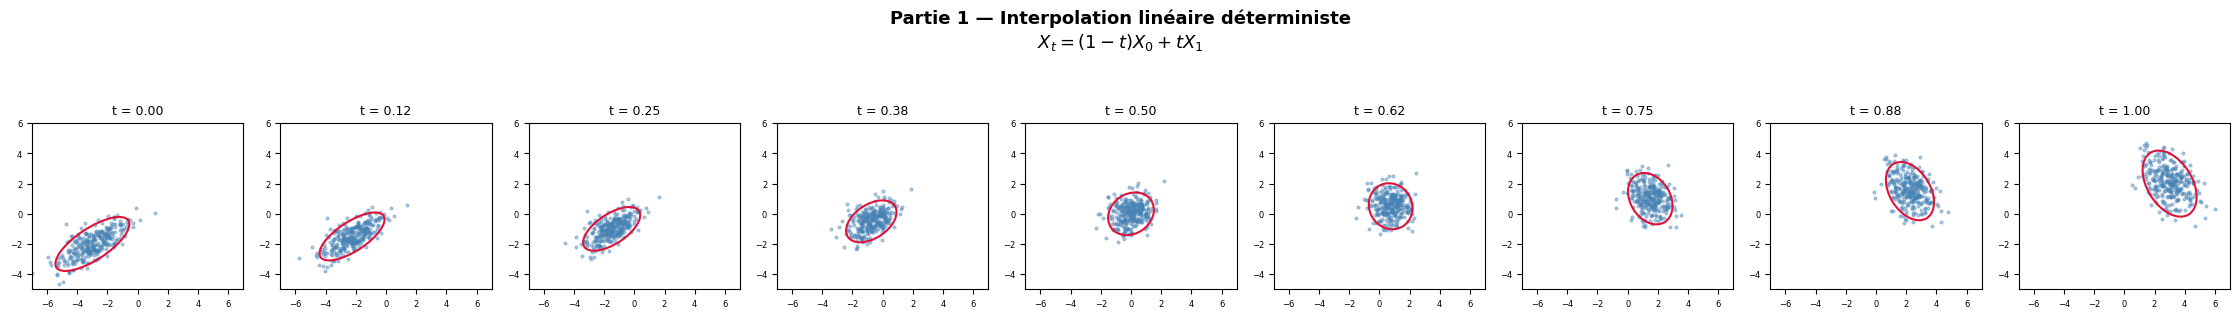

In [11]:
fig, axes = plt.subplots(1, T_steps, figsize=(T_steps * 2.5, 3.5))
fig.suptitle("Partie 1 — Interpolation linéaire déterministe\n$X_t = (1-t)X_0 + tX_1$",
             fontsize=13, fontweight='bold')

for ax, t in zip(axes, times):
    Xt = (1 - t) * X0 + t * X1
    mt, St = interp_gaussian_params(m0, S0, m1, S1, t)

    ax.scatter(Xt[:, 0], Xt[:, 1], s=4, alpha=0.4, color='steelblue')
    draw_ellipse(ax, mt, St, n_std=2,
                 edgecolor='crimson', facecolor='none', linewidth=1.5)
    ax.set_xlim(-7, 7)
    ax.set_ylim(-5, 6)
    ax.set_title(f"t = {t:.2f}", fontsize=9)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=6)

plt.tight_layout()
plt.show()

## Partie 2 : Interpolation Stochastique
On ajoute $\sigma \cdot t(1-t) \epsilon$ le bruit s'annule aux bords donc $\mu1$ et $\mu2$ sont conservé mais le chemin est bruité d'un facteur $\sigma$ de sorte que,
$$ X_t = (1-t)X_0 + tX_1 + \sigma t(1-t) \epsilon \quad ou \quad \epsilon \sim \mathcal{N}(0,\textbf{I})$$

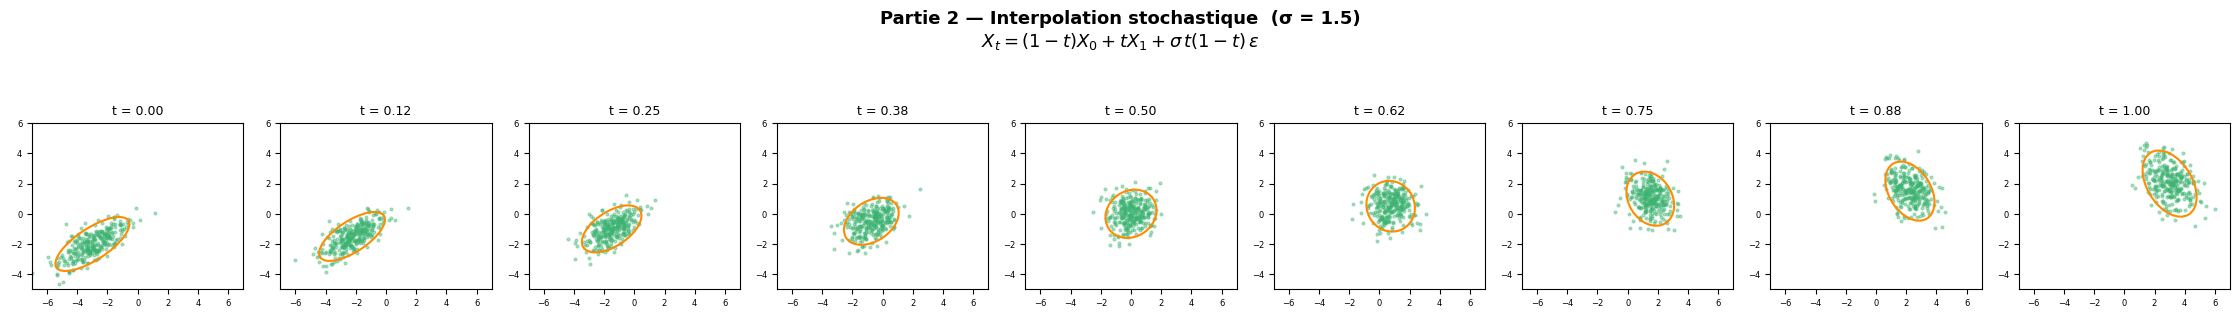

In [19]:
sigma = 1.5   # amplitude du bruit intermédiaire


fig, axes = plt.subplots(1, T_steps, figsize=(T_steps * 2.5, 3.5))
fig.suptitle(f"Partie 2 — Interpolation stochastique  (σ = {sigma})\n"
             r"$X_t = (1-t)X_0 + tX_1 + \sigma\,t(1-t)\,\epsilon$",
             fontsize=13, fontweight='bold')

for ax, t in zip(axes, times):
    eps = np.random.randn(N, 2)
    Xt = (1 - t) * X0 + t * X1 + sigma * t * (1 - t) * eps

    # Paramètres théoriques de la marginale
    mt, St = interp_gaussian_params(m0, S0, m1, S1, t)
    St_stoch = St + (sigma * t * (1 - t))**2 * np.eye(2)

    ax.scatter(Xt[:, 0], Xt[:, 1], s=4, alpha=0.4, color='mediumseagreen')
    draw_ellipse(ax, mt, St_stoch, n_std=2,
                 edgecolor='darkorange', facecolor='none', linewidth=1.5)
    ax.set_xlim(-7, 7)
    ax.set_ylim(-5, 6)
    ax.set_title(f"t = {t:.2f}", fontsize=9)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=6)

plt.tight_layout()
plt.show()

## Partie 3 : Schrödinger bridge gaussien

Entre deux gaussiennes, le SB admet une solution analytique. Le processus optimal est un "pont gaussien" :
$$ X_t = (1-t)X_0 + tX_1 + W_t^0 $$
où $W_t^0$ est un pont brownien (mouvement brownien conditionné à revenir à 0). La covariance du pont brownien à l'instant t est : $t(1-t) \textbf{I}$

En pratique :
$$ X_t = (1-t)X_0 + tX_1 + \sqrt{t(1-t)} \; \epsilon $$
( le bruit a une enveloppe $\sqrt{t(1-t)}$ au lieu de $t(1-t)$ )

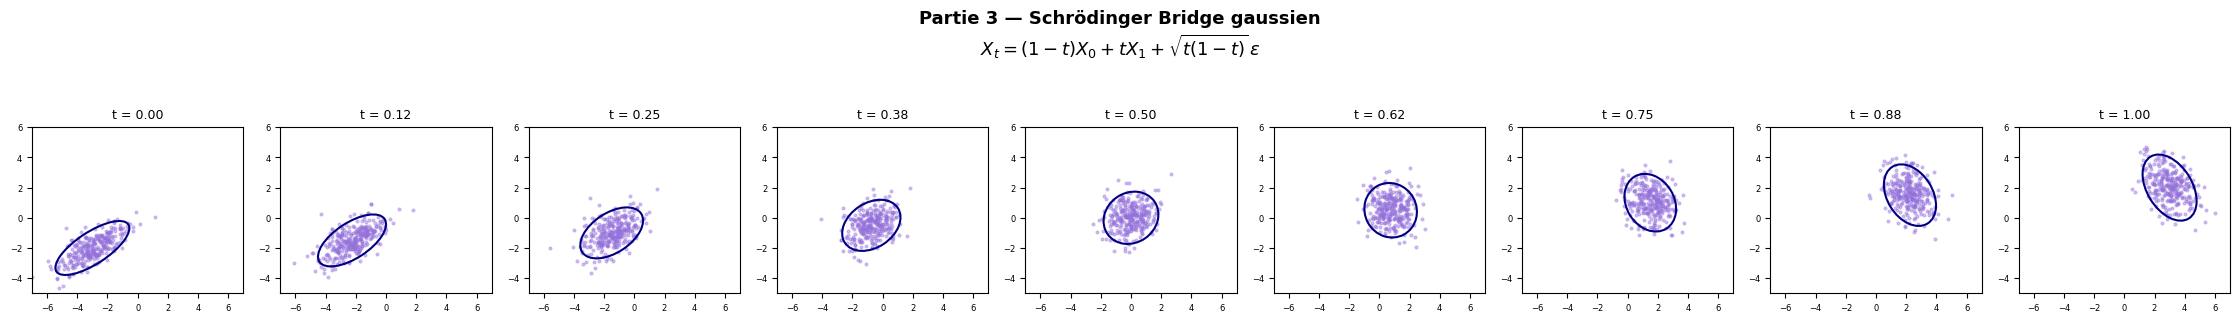

In [21]:
# Comparaison des enveloppes de bruit
t_range = np.linspace(0, 1, 200)
noise_stoch = sigma * t_range * (1 - t_range)      # Partie 2
noise_sb    = np.sqrt(t_range * (1 - t_range))     # Schrödinger Bridge

fig, axes = plt.subplots(1, T_steps, figsize=(T_steps * 2.5, 3.5))
fig.suptitle("Partie 3 — Schrödinger Bridge gaussien\n"
             r"$X_t = (1-t)X_0 + tX_1 + \sqrt{t(1-t)}\,\epsilon$",
             fontsize=13, fontweight='bold')

for ax, t in zip(axes, times):
    eps = np.random.randn(N, 2)
    Xt = (1 - t) * X0 + t * X1 + np.sqrt(t * (1 - t)) * eps

    mt, St = interp_gaussian_params(m0, S0, m1, S1, t)
    St_sb = St + t * (1 - t) * np.eye(2)

    ax.scatter(Xt[:, 0], Xt[:, 1], s=4, alpha=0.4, color='mediumpurple')
    draw_ellipse(ax, mt, St_sb, n_std=2,
                 edgecolor='navy', facecolor='none', linewidth=1.5)
    ax.set_xlim(-7, 7)
    ax.set_ylim(-5, 6)
    ax.set_title(f"t = {t:.2f}", fontsize=9)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=6)

plt.tight_layout()
plt.show()

## Comparaison de 3 parties précedente 

On visualise le chemon de quelques particules pour chaque méthode.

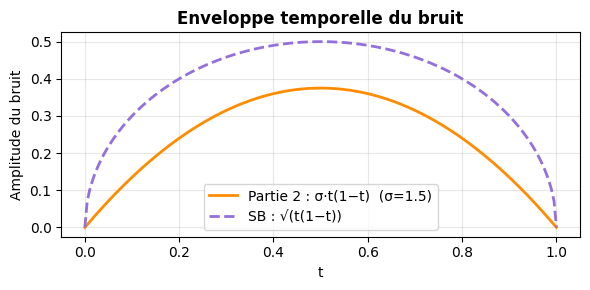

In [22]:
fig_noise, ax_noise = plt.subplots(figsize=(6, 3))
ax_noise.plot(t_range, noise_stoch, label=f"Partie 2 : σ·t(1−t)  (σ={sigma})",
              color='darkorange', linewidth=2)
ax_noise.plot(t_range, noise_sb, label="SB : √(t(1−t))",
              color='mediumpurple', linewidth=2, linestyle='--')
ax_noise.set_xlabel("t")
ax_noise.set_ylabel("Amplitude du bruit")
ax_noise.set_title("Enveloppe temporelle du bruit", fontweight='bold')
ax_noise.legend()
ax_noise.grid(alpha=0.3)
plt.tight_layout()
plt.show()

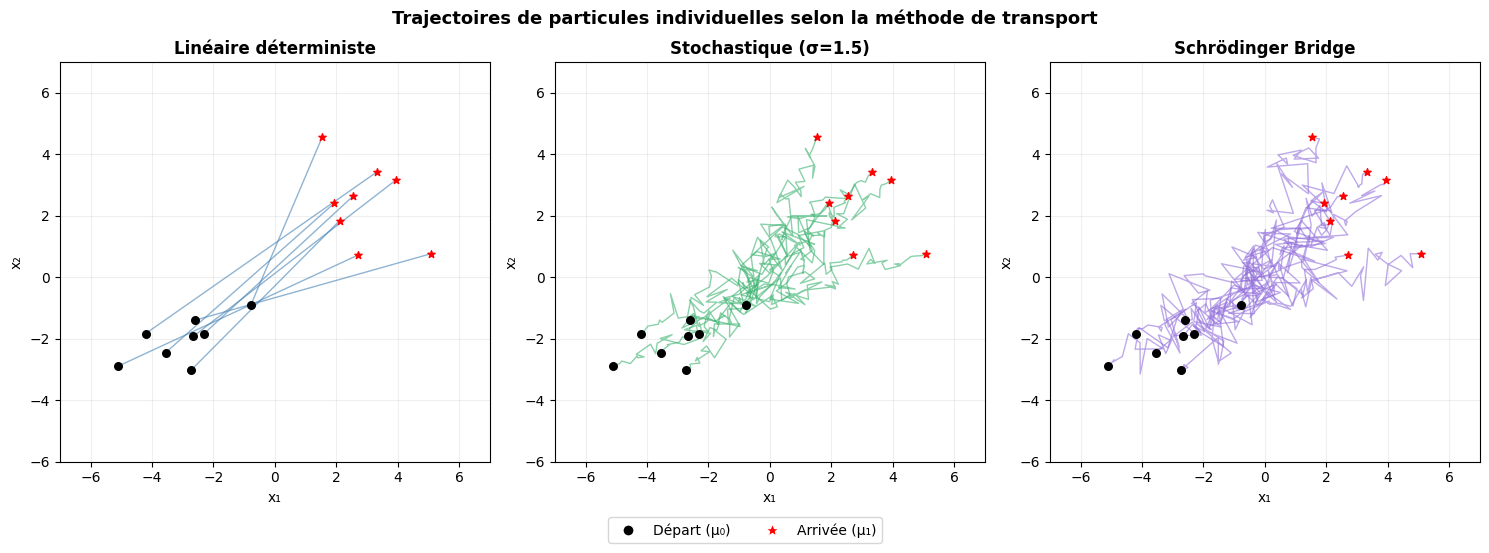

In [24]:
n_particles = 8
T_fine = np.linspace(0, 1, 50)
idx = np.arange(n_particles)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ["Linéaire déterministe", f"Stochastique (σ={sigma})", "Schrödinger Bridge"]
colors = ['steelblue', 'mediumseagreen', 'mediumpurple']

for col, (ax, title, color) in enumerate(zip(axes, titles, colors)):
    for i in idx:
        traj = []
        for t in T_fine:
            if col == 0:
                # Déterministe
                xt = (1 - t) * X0[i] + t * X1[i]
            elif col == 1:
                # Stochastique (bruit différent à chaque t → chemin bruité)
                eps = np.random.randn(2)
                xt = (1 - t) * X0[i] + t * X1[i] + sigma * t * (1 - t) * eps
            else:
                # Schrödinger Bridge
                eps = np.random.randn(2)
                xt = (1 - t) * X0[i] + t * X1[i] + np.sqrt(t * (1 - t)) * eps
            traj.append(xt)
        traj = np.array(traj)
        ax.plot(traj[:, 0], traj[:, 1], color=color, alpha=0.6, linewidth=1)
        ax.scatter(*X0[i], color='black', s=30, zorder=5)
        ax.scatter(*X1[i], color='red', s=30, zorder=5, marker='*')

    ax.set_title(title, fontweight='bold')
    ax.set_xlim(-7, 7)
    ax.set_ylim(-6, 7)
    ax.set_aspect('equal')
    ax.grid(alpha=0.2)
    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")

# Légende commune
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='black',
                           markersize=8, label='Départ (μ₀)'),
                   Line2D([0], [0], marker='*', color='w', markerfacecolor='red',
                           markersize=10, label='Arrivée (μ₁)')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.1))

fig.suptitle("Trajectoires de particules individuelles selon la méthode de transport",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()